In [31]:
import pandas as pd
import numpy as np
from pathlib import Path
import matplotlib.pyplot as plt
import seaborn as sns


### Nivell 1, Ejercicio 1

In [126]:
df_treballadors = pd.read_excel(
    "sprint10.xlsx",
    header=3,
    index_col=0
)

df_ordenat = df_treballadors.sort_values(
    by=["País d'origen", "Ciutat"],
    ascending=[True, True]
)

display(df_ordenat.head(10))

print(f"El DNI només té valors únics? {'Sí' if df_treballadors['DNI'].is_unique else 'No'}")

,Nom,Cognoms,DNI,País d'origen,Ciutat,Dia de Naixement,Mes de Naixement,Any de Naixement,Gènere,Salari mensual,Fills,No Fills,Grup Professional
21,Mia,Schneider Fischer,28973553Z,Alemanya,Berlín,22,10,1976,A,951 €,NaN,1.0,Grup A
154,Laura,Schneider Fischer,37399141L,Alemanya,Berlín,2,2,1958,D,1.769 €,1.0,NaN,Grup B
224,Lea,Schneider Schneider,37368317L,Alemanya,Berlín,23,10,2005,D,2.013 €,NaN,1.0,Grup B
278,Mia,Fischer,21390098Z,Alemanya,Berlín,11,8,1950,D,1.557 €,1.0,NaN,Grup B
602,Jonas,Schneider,44060014R,Alemanya,Berlín,22,11,1985,H,2.754 €,1.0,NaN,Grup D
871,Lea,Fischer,14773153R,Alemanya,Berlín,9,9,1986,D,1.370 €,1.0,NaN,Grup A
281,Lea,Müller,23266650S,Alemanya,Hamburg,14,4,2003,D,1.314 €,NaN,1.0,Grup A
435,Anna,Müller,83274277X,Alemanya,Hamburg,1,1,1987,D,2.464 €,NaN,1.0,Grup C
444,Laura,Schmidt Müller,60161784X,Alemanya,Hamburg,15,6,1987,NC,2.035 €,1.0,NaN,Grup C
487,Lukas,Müller Fischer,60982309S,Alemanya,Hamburg,28,3,1971,H,2.042 €,NaN,1.0,Grup B


El DNI només té valors únics? Sí


### Nivell 1, Ejercicio 2

In [127]:
df_treballadors["Nom Complet"] = (
    df_treballadors["Nom"] + " " + df_treballadors["Cognoms"]
)

df_treballadors["Nascut a Espanya"] = np.where(
    df_treballadors["País d'origen"] == "Espanya",
    "Sí",
    "No"
)

df_treballadors = df_treballadors.set_index("DNI")

df_treballadors = df_treballadors.rename(columns={
    "Dia de Naixement": "Dia",
    "Mes de Naixement": "Mes",
    "Any de Naixement": "Any"
})

df_treballadors["Gènere"] = df_treballadors["Gènere"].replace({
    "H": "Home",
    "D": "Dona",
    "A": "Altres",
    "NC": np.nan
})

display(df_treballadors)

,Nom,Cognoms,País d'origen,Ciutat,Dia,Mes,Any,Gènere,Salari mensual,Fills,No Fills,Grup Professional,Nom Complet,Nascut a Espanya
DNI,,,,,,,,,,,,,,
16928694K,Inês,Ferreira Silva,Portugal,Lisboa,25,2,1953,Dona,1.144 €,NaN,1.0,Grup B,Inês Ferreira Silva,No
27724652S,Clara,Sánchez Martínez,Espanya,Barcelona,18,3,1996,Dona,1.253 €,1.0,NaN,Grup A,Clara Sánchez Martínez,Sí
38141675A,Fatima,Fassi,Marroc,Rabat,6,11,2005,Altres,1.441 €,1.0,NaN,Grup A,Fatima Fassi,No
59157262R,Khadija,Bennani Bennani,Marroc,Rabat,20,1,1995,Dona,1.944 €,NaN,1.0,Grup B,Khadija Bennani Bennani,No
69630528M,Toni,Sánchez García,Espanya,Barcelona,9,8,1999,Home,1.043 €,NaN,1.0,Grup A,Toni Sánchez García,Sí
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
25161375F,Marta,Ferrer Ferrer,Espanya,Sevilla,1,6,1951,Dona,1.216 €,NaN,1.0,Grup B,Marta Ferrer Ferrer,Sí
52145541P,Joan,García,Espanya,Sevilla,11,4,1959,Home,971 €,NaN,1.0,Grup A,Joan García,Sí
69760120X,Laia,Ferrer Martínez,Espanya,Barcelona,11,11,1980,Dona,682 €,NaN,1.0,Grup A,Laia Ferrer Martínez,Sí


### Nivell 1, Ejercicio 3

In [128]:
def obtenir_fills(fila):
    
    if pd.notna(fila["Fills"]):
        return "Sí"
    
    elif pd.notna(fila["No Fills"]):
        return "No"


df_treballadors["Fills"] = df_treballadors.apply(obtenir_fills, axis=1)

df_treballadors = df_treballadors.drop(columns=["No Fills"])

display(df_treballadors)

,Nom,Cognoms,País d'origen,Ciutat,Dia,Mes,Any,Gènere,Salari mensual,Fills,Grup Professional,Nom Complet,Nascut a Espanya
DNI,,,,,,,,,,,,,
16928694K,Inês,Ferreira Silva,Portugal,Lisboa,25,2,1953,Dona,1.144 €,No,Grup B,Inês Ferreira Silva,No
27724652S,Clara,Sánchez Martínez,Espanya,Barcelona,18,3,1996,Dona,1.253 €,Sí,Grup A,Clara Sánchez Martínez,Sí
38141675A,Fatima,Fassi,Marroc,Rabat,6,11,2005,Altres,1.441 €,Sí,Grup A,Fatima Fassi,No
59157262R,Khadija,Bennani Bennani,Marroc,Rabat,20,1,1995,Dona,1.944 €,No,Grup B,Khadija Bennani Bennani,No
69630528M,Toni,Sánchez García,Espanya,Barcelona,9,8,1999,Home,1.043 €,No,Grup A,Toni Sánchez García,Sí
...,...,...,...,...,...,...,...,...,...,...,...,...,...
25161375F,Marta,Ferrer Ferrer,Espanya,Sevilla,1,6,1951,Dona,1.216 €,No,Grup B,Marta Ferrer Ferrer,Sí
52145541P,Joan,García,Espanya,Sevilla,11,4,1959,Home,971 €,No,Grup A,Joan García,Sí
69760120X,Laia,Ferrer Martínez,Espanya,Barcelona,11,11,1980,Dona,682 €,No,Grup A,Laia Ferrer Martínez,Sí


### Nivell 1, Ejercicio 4

In [129]:
def netejar_salari(salari):
    
    if pd.isna(salari):
        return np.nan
    
    text = str(salari).strip()
    text = text.replace("€", "")
    text = text.replace(".", "")
    text = text.replace(",", ".")
    
    return float(text)


df_treballadors["Salari mensual"] = df_treballadors["Salari mensual"].apply(netejar_salari)

taula_salaris = (
    df_treballadors
    .groupby("Gènere")["Salari mensual"]
    .agg(
        Sou_mig="mean",
        Sou_medià="median",
        Sou_mínim="min",
        Sou_màxim="max"
    )
    .sort_values(by="Sou_mig", ascending=False)
    .round(2)
)

display(taula_salaris)

,Sou_mig,Sou_medià,Sou_mínim,Sou_màxim
Gènere,,,,
Home,1643.25,1531.0,737.0,3356.0
Altres,1626.59,1545.0,703.0,3175.0
Dona,1469.44,1361.5,665.0,3021.0


### Nivell 1, Ejercicio 5

In [131]:
taula_salari_genere_pais = df_treballadors.pivot_table(
    index="Gènere",
    columns="País d'origen",
    values="Salari mensual",
    aggfunc="mean",
    margins=True,
    margins_name="Mitjana General"
).round(2)

taula_salari_genere_pais.style.format("{:.2f}").background_gradient(
    cmap="Greens",
    axis=None
)


País d'origen,Alemanya,Argentina,Colòmbia,Espanya,França,Itàlia,Marroc,Mèxic,Portugal,Regne Unit,Mitjana General
Gènere,,,,,,,,,,,
Altres,9510.00,11410.00,10300.00,17061.76,nan,14230.00,13650.00,13720.00,17650.00,19210.00,16265.88
Dona,18043.08,12918.00,14977.50,14601.64,15664.71,12471.82,14052.14,15178.00,14885.45,14894.62,14694.43
Home,20674.29,15832.94,15546.67,16821.06,13892.50,16728.75,15310.00,16250.00,14970.00,11625.56,16432.49
Mitjana General,18513.81,14633.93,14955.41,15812.10,14627.32,14259.55,14473.33,15584.17,15233.33,14235.60,15609.89


In [132]:
display(df_treballadors)

,Nom,Cognoms,País d'origen,Ciutat,Dia,Mes,Any,Gènere,Salari mensual,Fills,Grup Professional,Nom Complet,Nascut a Espanya
DNI,,,,,,,,,,,,,
16928694K,Inês,Ferreira Silva,Portugal,Lisboa,25,2,1953,Dona,11440.0,No,Grup B,Inês Ferreira Silva,No
27724652S,Clara,Sánchez Martínez,Espanya,Barcelona,18,3,1996,Dona,12530.0,Sí,Grup A,Clara Sánchez Martínez,Sí
38141675A,Fatima,Fassi,Marroc,Rabat,6,11,2005,Altres,14410.0,Sí,Grup A,Fatima Fassi,No
59157262R,Khadija,Bennani Bennani,Marroc,Rabat,20,1,1995,Dona,19440.0,No,Grup B,Khadija Bennani Bennani,No
69630528M,Toni,Sánchez García,Espanya,Barcelona,9,8,1999,Home,10430.0,No,Grup A,Toni Sánchez García,Sí
...,...,...,...,...,...,...,...,...,...,...,...,...,...
25161375F,Marta,Ferrer Ferrer,Espanya,Sevilla,1,6,1951,Dona,12160.0,No,Grup B,Marta Ferrer Ferrer,Sí
52145541P,Joan,García,Espanya,Sevilla,11,4,1959,Home,9710.0,No,Grup A,Joan García,Sí
69760120X,Laia,Ferrer Martínez,Espanya,Barcelona,11,11,1980,Dona,6820.0,No,Grup A,Laia Ferrer Martínez,Sí


### Nivell 1, Ejercicio 6

In [133]:
df_treballadors["Data Naixement"] = pd.to_datetime({
    "year": df_treballadors["Any"],
    "month": df_treballadors["Mes"],
    "day": df_treballadors["Dia"]
})


def calcular_edat(data_naixement):
    
    avui = pd.Timestamp.today()
    
    edat = avui.year - data_naixement.year
    
    if (avui.month, avui.day) < (data_naixement.month, data_naixement.day):
        edat -= 1
        
    return edat


df_treballadors["Edat"] = df_treballadors["Data Naixement"].apply(calcular_edat)

display(df_treballadors)

,Nom,Cognoms,País d'origen,Ciutat,Dia,Mes,Any,Gènere,Salari mensual,Fills,Grup Professional,Nom Complet,Nascut a Espanya,Data Naixement,Edat
DNI,,,,,,,,,,,,,,,
16928694K,Inês,Ferreira Silva,Portugal,Lisboa,25,2,1953,Dona,11440.0,No,Grup B,Inês Ferreira Silva,No,1953-02-25,73
27724652S,Clara,Sánchez Martínez,Espanya,Barcelona,18,3,1996,Dona,12530.0,Sí,Grup A,Clara Sánchez Martínez,Sí,1996-03-18,30
38141675A,Fatima,Fassi,Marroc,Rabat,6,11,2005,Altres,14410.0,Sí,Grup A,Fatima Fassi,No,2005-11-06,20
59157262R,Khadija,Bennani Bennani,Marroc,Rabat,20,1,1995,Dona,19440.0,No,Grup B,Khadija Bennani Bennani,No,1995-01-20,31
69630528M,Toni,Sánchez García,Espanya,Barcelona,9,8,1999,Home,10430.0,No,Grup A,Toni Sánchez García,Sí,1999-08-09,26
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
25161375F,Marta,Ferrer Ferrer,Espanya,Sevilla,1,6,1951,Dona,12160.0,No,Grup B,Marta Ferrer Ferrer,Sí,1951-06-01,75
52145541P,Joan,García,Espanya,Sevilla,11,4,1959,Home,9710.0,No,Grup A,Joan García,Sí,1959-04-11,67
69760120X,Laia,Ferrer Martínez,Espanya,Barcelona,11,11,1980,Dona,6820.0,No,Grup A,Laia Ferrer Martínez,Sí,1980-11-11,45


### Nivell 2, Ejercicio 1

In [134]:
df_increment = pd.DataFrame({
    "Grup": ["Grup A", "Grup B", "Grup C", "Grup D"],
    "Increment": ["5%", "3,5%", "2%", "8%"]
})

In [ ]:
df_treballadors = df_treballadors.join(
    df_increment.set_index("Grup"),
    on="Grup Professional"
)

In [136]:
display(df_treballadors)

,Nom,Cognoms,País d'origen,Ciutat,Dia,Mes,Any,Gènere,Salari mensual,Fills,Grup Professional,Nom Complet,Nascut a Espanya,Data Naixement,Edat,Increment
DNI,,,,,,,,,,,,,,,,
16928694K,Inês,Ferreira Silva,Portugal,Lisboa,25,2,1953,Dona,11440.0,No,Grup B,Inês Ferreira Silva,No,1953-02-25,73,"3,5%"
27724652S,Clara,Sánchez Martínez,Espanya,Barcelona,18,3,1996,Dona,12530.0,Sí,Grup A,Clara Sánchez Martínez,Sí,1996-03-18,30,5%
38141675A,Fatima,Fassi,Marroc,Rabat,6,11,2005,Altres,14410.0,Sí,Grup A,Fatima Fassi,No,2005-11-06,20,5%
59157262R,Khadija,Bennani Bennani,Marroc,Rabat,20,1,1995,Dona,19440.0,No,Grup B,Khadija Bennani Bennani,No,1995-01-20,31,"3,5%"
69630528M,Toni,Sánchez García,Espanya,Barcelona,9,8,1999,Home,10430.0,No,Grup A,Toni Sánchez García,Sí,1999-08-09,26,5%
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
25161375F,Marta,Ferrer Ferrer,Espanya,Sevilla,1,6,1951,Dona,12160.0,No,Grup B,Marta Ferrer Ferrer,Sí,1951-06-01,75,"3,5%"
52145541P,Joan,García,Espanya,Sevilla,11,4,1959,Home,9710.0,No,Grup A,Joan García,Sí,1959-04-11,67,5%
69760120X,Laia,Ferrer Martínez,Espanya,Barcelona,11,11,1980,Dona,6820.0,No,Grup A,Laia Ferrer Martínez,Sí,1980-11-11,45,5%


In [ ]:
df_treballadors["Increment decimal"] = (
    df_treballadors["Increment"]
    .str.replace("%", "")
    .str.replace(",", ".")
    .astype(float) / 100
)

In [138]:
display(df_treballadors)

,Nom,Cognoms,País d'origen,Ciutat,Dia,Mes,Any,Gènere,Salari mensual,Fills,Grup Professional,Nom Complet,Nascut a Espanya,Data Naixement,Edat,Increment,Increment decimal
DNI,,,,,,,,,,,,,,,,,
16928694K,Inês,Ferreira Silva,Portugal,Lisboa,25,2,1953,Dona,11440.0,No,Grup B,Inês Ferreira Silva,No,1953-02-25,73,"3,5%",0.035
27724652S,Clara,Sánchez Martínez,Espanya,Barcelona,18,3,1996,Dona,12530.0,Sí,Grup A,Clara Sánchez Martínez,Sí,1996-03-18,30,5%,0.050
38141675A,Fatima,Fassi,Marroc,Rabat,6,11,2005,Altres,14410.0,Sí,Grup A,Fatima Fassi,No,2005-11-06,20,5%,0.050
59157262R,Khadija,Bennani Bennani,Marroc,Rabat,20,1,1995,Dona,19440.0,No,Grup B,Khadija Bennani Bennani,No,1995-01-20,31,"3,5%",0.035
69630528M,Toni,Sánchez García,Espanya,Barcelona,9,8,1999,Home,10430.0,No,Grup A,Toni Sánchez García,Sí,1999-08-09,26,5%,0.050
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
25161375F,Marta,Ferrer Ferrer,Espanya,Sevilla,1,6,1951,Dona,12160.0,No,Grup B,Marta Ferrer Ferrer,Sí,1951-06-01,75,"3,5%",0.035
52145541P,Joan,García,Espanya,Sevilla,11,4,1959,Home,9710.0,No,Grup A,Joan García,Sí,1959-04-11,67,5%,0.050
69760120X,Laia,Ferrer Martínez,Espanya,Barcelona,11,11,1980,Dona,6820.0,No,Grup A,Laia Ferrer Martínez,Sí,1980-11-11,45,5%,0.050


In [ ]:
df_treballadors["Salari mensual"] = (
    df_treballadors["Salari mensual"] * 
    (1 + df_treballadors["Increment decimal"])
).round(2)

In [140]:
display(df_treballadors)

,Nom,Cognoms,País d'origen,Ciutat,Dia,Mes,Any,Gènere,Salari mensual,Fills,Grup Professional,Nom Complet,Nascut a Espanya,Data Naixement,Edat,Increment,Increment decimal
DNI,,,,,,,,,,,,,,,,,
16928694K,Inês,Ferreira Silva,Portugal,Lisboa,25,2,1953,Dona,11840.4,No,Grup B,Inês Ferreira Silva,No,1953-02-25,73,"3,5%",0.035
27724652S,Clara,Sánchez Martínez,Espanya,Barcelona,18,3,1996,Dona,13156.5,Sí,Grup A,Clara Sánchez Martínez,Sí,1996-03-18,30,5%,0.050
38141675A,Fatima,Fassi,Marroc,Rabat,6,11,2005,Altres,15130.5,Sí,Grup A,Fatima Fassi,No,2005-11-06,20,5%,0.050
59157262R,Khadija,Bennani Bennani,Marroc,Rabat,20,1,1995,Dona,20120.4,No,Grup B,Khadija Bennani Bennani,No,1995-01-20,31,"3,5%",0.035
69630528M,Toni,Sánchez García,Espanya,Barcelona,9,8,1999,Home,10951.5,No,Grup A,Toni Sánchez García,Sí,1999-08-09,26,5%,0.050
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
25161375F,Marta,Ferrer Ferrer,Espanya,Sevilla,1,6,1951,Dona,12585.6,No,Grup B,Marta Ferrer Ferrer,Sí,1951-06-01,75,"3,5%",0.035
52145541P,Joan,García,Espanya,Sevilla,11,4,1959,Home,10195.5,No,Grup A,Joan García,Sí,1959-04-11,67,5%,0.050
69760120X,Laia,Ferrer Martínez,Espanya,Barcelona,11,11,1980,Dona,7161.0,No,Grup A,Laia Ferrer Martínez,Sí,1980-11-11,45,5%,0.050


### Nivell 2, Ejercicio 2

In [29]:
for grup in df_treballadors["Grup Professional"].unique():
    
    df_grup = df_treballadors[
        df_treballadors["Grup Professional"] == grup
    ]
    
    nom_fitxer = f"dades_{grup.replace(' ', '')}.xlsx"
    
    df_grup.to_excel(nom_fitxer)
    
    print(f"Exportat: {nom_fitxer}")

Exportat: dades_GrupB.xlsx
Exportat: dades_GrupA.xlsx
Exportat: dades_GrupD.xlsx
Exportat: dades_GrupC.xlsx


In [30]:
df_resum_grups = (
    df_treballadors
    .groupby("Grup Professional")
    .agg(
        Num_treballadors=("Nom Complet", "count"),
        Sou_mig=("Salari mensual", "mean"),
        Edat_mediana=("Edat", "median")
    )
    .round(2)
)

df_resum_grups.to_excel("resum_grups.xlsx")

display(df_resum_grups)

,Num_treballadors,Sou_mig,Edat_mediana
Grup Professional,,,
Grup A,490,1213.32,51.0
Grup B,318,1724.55,48.0
Grup C,137,2289.19,52.0
Grup D,55,3100.82,44.0


### Nivell 3, Ejercicio 1

In [ ]:
def crear_grafics(df):
    
    carpeta = Path("grafics_automatics")
    carpeta.mkdir(exist_ok=True)
    
    for columna in df.columns:
        
        plt.figure(figsize=(8, 4))
        
        if pd.api.types.is_numeric_dtype(df[columna]) and not pd.api.types.is_bool_dtype(df[columna]):
            
            plt.subplot(1, 2, 1)
            df[columna].dropna().plot(kind="hist", bins=15) 
            plt.title(f"Histograma de {columna}")
            
            plt.subplot(1, 2, 2)
            plt.boxplot(df[columna].dropna())
            plt.title(f"Boxplot de {columna}")
            
        elif pd.api.types.is_datetime64_any_dtype(df[columna]):
            
            df[columna].dt.year.value_counts().sort_index().plot(kind="bar")
            plt.title(f"Anys més freqüents de {columna}")
            
        else:
            
            df[columna].dropna().value_counts().head(15).plot(kind="bar")
            plt.title(f"Valors més freqüents de {columna}")
        
        plt.tight_layout()
        
        nom_columna = columna.replace(" ", "_").replace("/", "_")
        plt.savefig(carpeta / f"grafic_{nom_columna}.png")
        
        plt.show()
        plt.close()

,species,island,bill_length_mm,bill_depth_mm,flipper_length_mm,body_mass_g,sex
0,Adelie,Torgersen,39.1,18.7,181.0,3750.0,Male
1,Adelie,Torgersen,39.5,17.4,186.0,3800.0,Female
2,Adelie,Torgersen,40.3,18.0,195.0,3250.0,Female
3,Adelie,Torgersen,NaN,NaN,NaN,NaN,NaN
4,Adelie,Torgersen,36.7,19.3,193.0,3450.0,Female


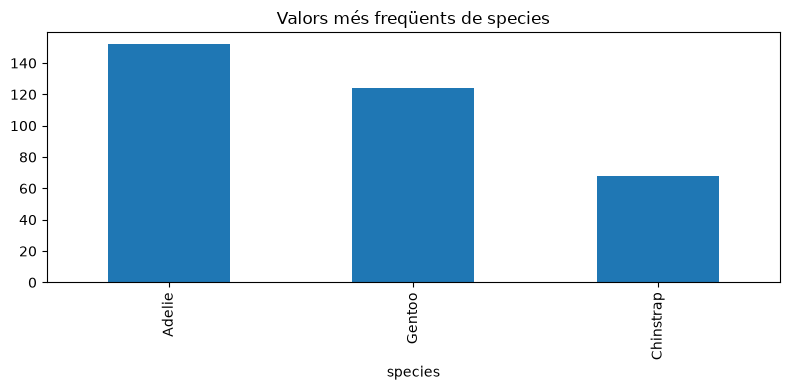

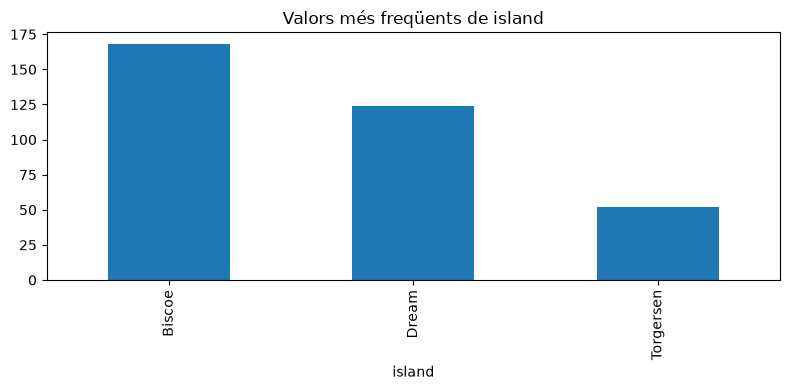

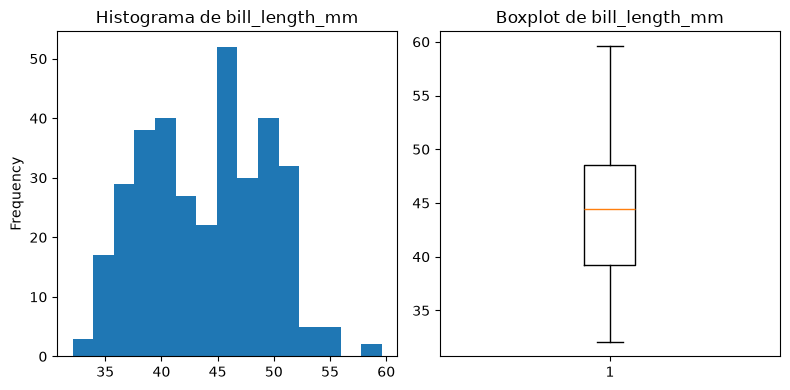

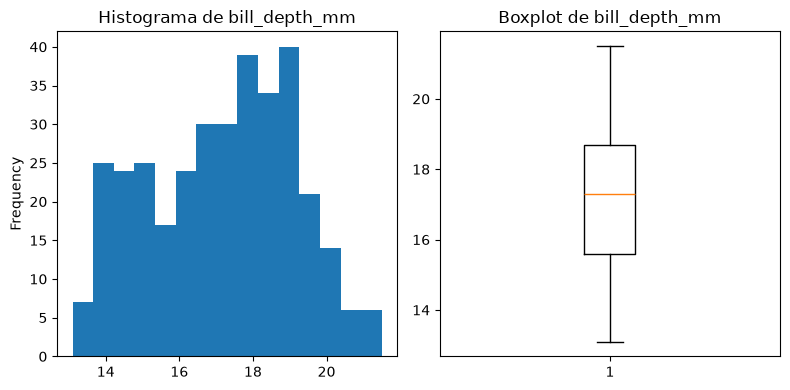

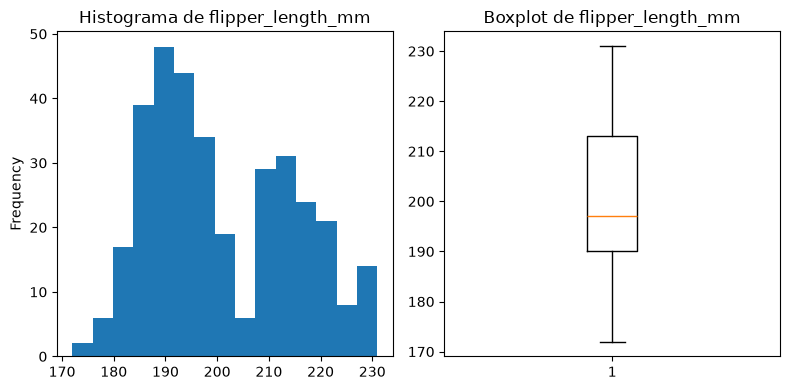

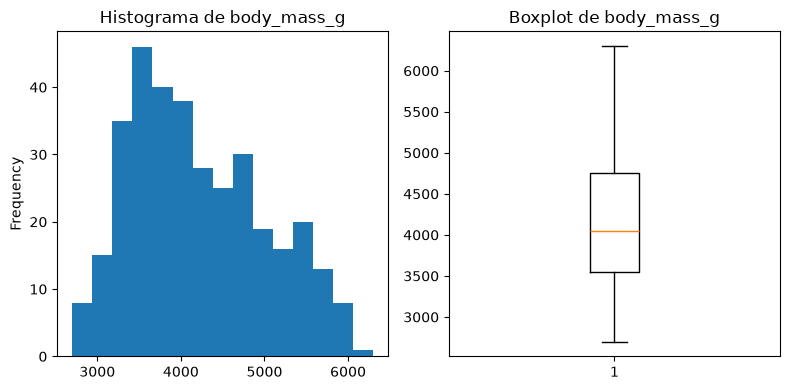

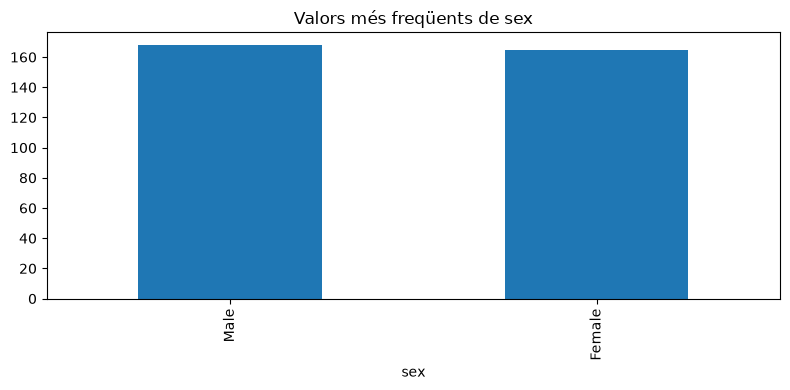

In [33]:
df_penguins = sns.load_dataset("penguins")

display(df_penguins.head())

crear_grafics(df_penguins)

### Nivell 3, Ejercicio 2

In [143]:
matriu_distancies = pd.read_excel(
    "matriu_distancies.xlsx",
    index_col=0
)

matriu_distancies = matriu_distancies.drop(
    index=["Las Palmas de Gran Canaria", "Palma"],
    columns=["Las Palmas de Gran Canaria", "Palma"]
)

display(matriu_distancies)

,Barcelona,Valencia,Sevilla,Zaragoza,Málaga,Murcia,Bilbao,Alicante,Córdoba,Valladolid,Vigo,Gijón,Hospitalet de Llobregat
Barcelona,NaN,303.0,831.0,256.0,770.0,471.0,469.0,407.0,711.0,576.0,908.0,686.0,7.0
Valencia,303.0,NaN,541.0,246.0,468.0,177.0,473.0,125.0,421.0,441.0,766.0,632.0,297.0
Sevilla,831.0,541.0,NaN,646.0,158.0,433.0,703.0,495.0,121.0,486.0,588.0,685.0,824.0
Zaragoza,256.0,246.0,646.0,NaN,628.0,408.0,246.0,368.0,535.0,320.0,652.0,444.0,250.0
Málaga,770.0,468.0,158.0,628.0,NaN,323.0,739.0,391.0,133.0,549.0,716.0,766.0,763.0
Murcia,471.0,177.0,433.0,408.0,323.0,NaN,606.0,69.0,320.0,510.0,800.0,726.0,465.0
Bilbao,469.0,473.0,703.0,246.0,739.0,606.0,NaN,583.0,618.0,232.0,486.0,223.0,465.0
Alicante,407.0,125.0,495.0,368.0,391.0,69.0,583.0,NaN,379.0,515.0,821.0,722.0,401.0
Córdoba,711.0,421.0,121.0,535.0,133.0,320.0,618.0,379.0,NaN,419.0,589.0,634.0,704.0
Valladolid,576.0,441.0,486.0,320.0,549.0,510.0,232.0,515.0,419.0,NaN,337.0,224.0,570.0


In [147]:
display(matriu_distancies.loc["Barcelona"])

Barcelona                    NaN
Valencia                   303.0
Sevilla                    831.0
Zaragoza                   256.0
Málaga                     770.0
Murcia                     471.0
Bilbao                     469.0
Alicante                   407.0
Córdoba                    711.0
Valladolid                 576.0
Vigo                       908.0
Gijón                      686.0
Hospitalet de Llobregat      7.0
Name: Barcelona, dtype: float64

In [167]:
def ciudad_mas_cercana_ultima(matriz, ciudad_actual, ciudades_visitadas):
    distancias = matriz.loc[ciudad_actual]

    mejor_ciudad = None
    mejor_distancia = float("inf")

    for ciudad in distancias.index:

        distancia = distancias[ciudad]

        if ciudad != ciudad_actual and ciudad not in ciudades_visitadas:
            if distancia < mejor_distancia:

                mejor_ciudad = ciudad
                mejor_distancia = distancia

    return mejor_ciudad, mejor_distancia


def crear_mejor_ruta_ultima(matriz, ciudad_origen):

    ruta = [ciudad_origen]
    ciudades_visitadas = [ciudad_origen]
    distancia_recorrida = 0

    ciudad_actual = ciudad_origen

    while len(ciudades_visitadas) < len(matriz.index):

        mejor_ciudad, mejor_distancia = ciudad_mas_cercana_ultima(
            matriz, ciudad_actual, ciudades_visitadas
        )

        ruta.append(mejor_ciudad)
        ciudades_visitadas.append(mejor_ciudad)
        distancia_recorrida += mejor_distancia

        ciudad_actual = mejor_ciudad

    return ruta, distancia_recorrida


ruta, distancia_recorrida = crear_mejor_ruta_ultima(matriu_distancies, "Barcelona")

print(f"La mejor ruta es: {ruta} \ny la distancia recorrida son {distancia_recorrida} kilómetros.")


La mejor ruta es: ['Barcelona', 'Hospitalet de Llobregat', 'Zaragoza', 'Valencia', 'Alicante', 'Murcia', 'Córdoba', 'Sevilla', 'Málaga', 'Valladolid', 'Gijón', 'Bilbao', 'Vigo'] 
y la distancia recorrida son 2778.0 kilómetros.
